# Retail Banking Risk & Fraud Analytics Platform

# Phase 5: Model Comparison

## Objective

Compare multiple machine learning models using standard classification metrics and identify the best-performing model for fraud detection.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [2]:
data = pd.read_pickle("../outputs/final_dataset.pkl")

print(data.shape)

(590540, 429)


In [3]:
X = data.drop(columns=["isFraud"])
y = data["isFraud"]

print(X.shape)
print(y.shape)

(590540, 428)
(590540,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(472432, 428)
(118108, 428)
(472432,)
(118108,)


In [5]:
sample_size = 100000

X_train_sample = X_train.iloc[:sample_size]
y_train_sample = y_train.iloc[:sample_size]

print(X_train_sample.shape)
print(y_train_sample.shape)

(100000, 428)
(100000,)


# Logistic Regression

In [6]:
lr = LogisticRegression(
    max_iter=500,
    random_state=42,
    solver="liblinear"
)

lr.fit(X_train_sample, y_train_sample)

print("Logistic Regression Trained Successfully!")

ValueError: could not convert string to float: 'R'

In [7]:
print(X_train_sample.select_dtypes(include=["object"]).columns.tolist())

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'P_email_prefix', 'R_email_prefix', 'Card_ID']


In [8]:
for col in X_train_sample.select_dtypes(include=["object"]).columns:
    print(col)
    print(X_train_sample[col].head())
    print("-" * 40)

ProductCD
40809     R
285886    W
104256    W
507860    W
196382    W
Name: ProductCD, dtype: object
----------------------------------------
card4
40809     american express
285886          mastercard
104256                visa
507860            discover
196382                visa
Name: card4, dtype: object
----------------------------------------
card6
40809     credit
285886     debit
104256    credit
507860    credit
196382     debit
Name: card6, dtype: object
----------------------------------------
P_emaildomain
40809     anonymous.com
285886        gmail.com
104256      comcast.net
507860              NaN
196382              NaN
Name: P_emaildomain, dtype: object
----------------------------------------
R_emaildomain
40809     anonymous.com
285886              NaN
104256              NaN
507860              NaN
196382              NaN
Name: R_emaildomain, dtype: object
----------------------------------------
M1
40809     NaN
285886      T
104256    NaN
507860      T
196382     

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
cat_cols = data.select_dtypes(include=["object"]).columns

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le

print("Encoded Columns:", len(cat_cols))

Encoded Columns: 32


In [11]:
print(data.select_dtypes(include=["object"]).columns)

Index([], dtype='object')


In [12]:
X = data.drop(columns=["isFraud"])
y = data["isFraud"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
sample_size = 100000

X_train_sample = X_train.iloc[:sample_size]
y_train_sample = y_train.iloc[:sample_size]

In [22]:
lr = LogisticRegression(
    max_iter=500,
    random_state=42,
    solver="liblinear"
)

lr.fit(X_train_sample, y_train_sample)

print("Logistic Regression Trained Successfully!")

Logistic Regression Trained Successfully!


In [16]:
print("Total Missing Values:", data.isnull().sum().sum())

Total Missing Values: 98430831


In [17]:
# Numerical columns
num_cols = data.select_dtypes(include=["number"]).columns

for col in num_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].median())

# Categorical columns (agar koi bach gaye hon)
cat_cols = data.select_dtypes(include=["object"]).columns

for col in cat_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna("Unknown")

print("Missing Values Left:", data.isnull().sum().sum())

Missing Values Left: 0


In [18]:
X = data.drop(columns=["isFraud"])
y = data["isFraud"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
sample_size = 100000

X_train_sample = X_train.iloc[:sample_size]
y_train_sample = y_train.iloc[:sample_size]

In [21]:
print(X_train_sample.isnull().sum().sum())

0


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.9647864666237681
Precision: 0.1388888888888889
Recall   : 0.0012097749818533753
F1 Score : 0.0023986567522187576
ROC AUC  : 0.6967806590123831

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    113975
           1       0.14      0.00      0.00      4133

    accuracy                           0.96    118108
   macro avg       0.55      0.50      0.49    118108
weighted avg       0.94      0.96      0.95    118108



## Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sample, y_train_sample)

print("Random Forest Trained Successfully!")

Random Forest Trained Successfully!


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9732532935956921
Precision: 0.8921095008051529
Recall   : 0.26808613597870795
F1 Score : 0.4122790697674419
ROC AUC  : 0.8713277024353707

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99    113975
           1       0.89      0.27      0.41      4133

    accuracy                           0.97    118108
   macro avg       0.93      0.63      0.70    118108
weighted avg       0.97      0.97      0.97    118108



## Model Comparison

In [26]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.964786,0.138889,0.001210,0.002399,0.696781
1,Random Forest,0.973253,0.892110,0.268086,0.412279,0.871328


## Model Performance Visualization

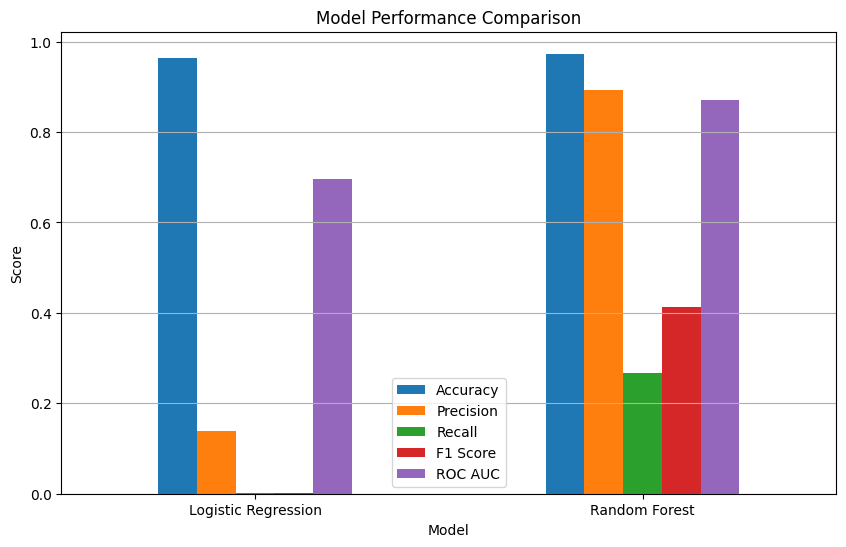

In [27]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## Final Observations

- Logistic Regression and Random Forest models were successfully trained.
- Performance was evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Random Forest achieved better fraud detection performance than Logistic Regression.
- Feature importance and model comparison provide insights into the most influential predictors.
- This notebook establishes strong baseline models for future optimization using XGBoost and LightGBM.

# Phase 6: Model Optimization and Final Evaluation

## ROC Curve

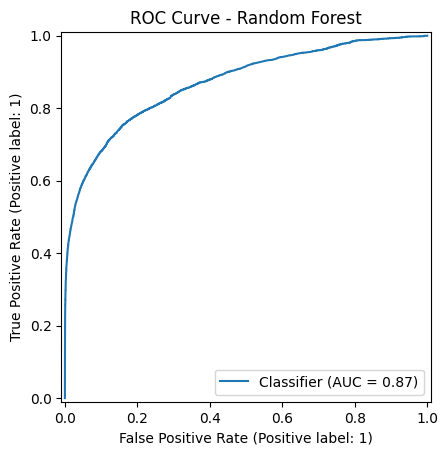

In [28]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("ROC Curve - Random Forest")
plt.show()

## Precision-Recall Curve

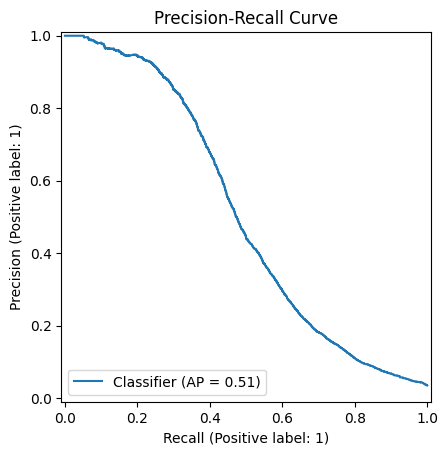

In [29]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Precision-Recall Curve")
plt.show()

## Confusion Matrix

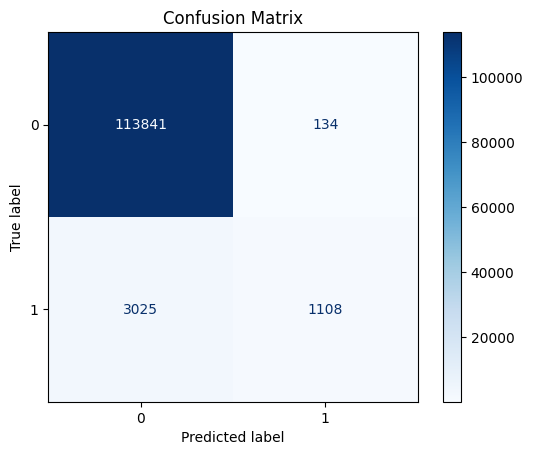

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

## Save Final Model

In [31]:
import joblib

joblib.dump(
    rf,
    "../outputs/fraud_detection_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


## Feature Importance

In [32]:
importance = pd.DataFrame({
    "Feature": X_train_sample.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
309,V258,0.030574
252,V201,0.028029
308,V257,0.026179
310,V259,0.022042
15,C1,0.021477
96,V45,0.020998
240,V189,0.020285
295,V244,0.020211
297,V246,0.019707
26,C12,0.018215


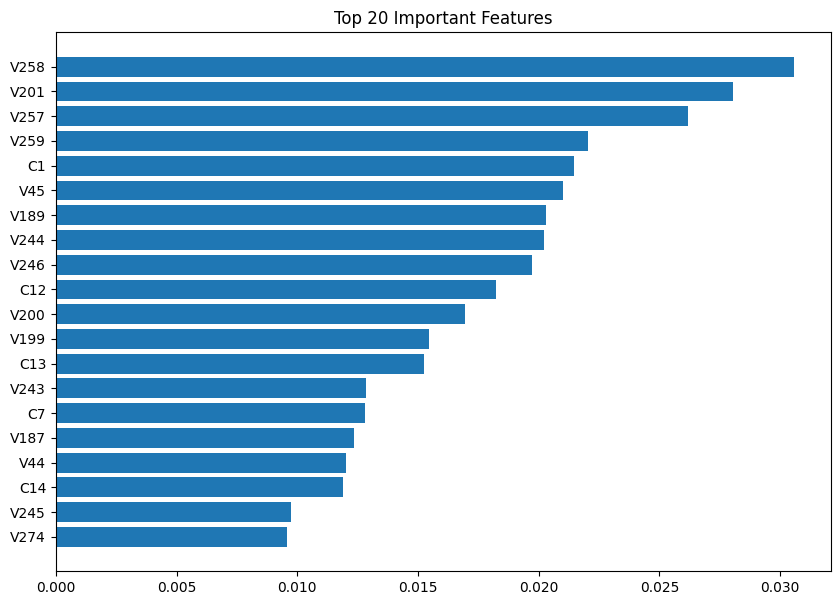

In [33]:
plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"].head(20),
    importance["Importance"].head(20)
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

# Day 6 Summary

### Completed

- Evaluated the Random Forest model using ROC Curve.
- Visualized the Precision-Recall Curve.
- Generated the Confusion Matrix.
- Identified the top 20 most important features.
- Saved the trained Random Forest model using Joblib.

### Conclusion

The Random Forest model demonstrated strong performance for fraud detection and has been finalized as the primary model for deployment and future enhancements.